### Luobin ###
### 21-09-2026 ###

In [1]:
import pandas as pd
import bambi as bmb
import numpy as np
import arviz as az

In [2]:
# read in data
data_file = "towelData.csv"
data = pd.read_csv(data_file, sep = ';', encoding = 'latin1' )
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set 
# can give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

# The model should use an appropriate family distribution for the response variable, and consider between study heterogeneity. 

The appropriate family distribution is binomial distribution, the outcome data will be the binary that the number of reuses yi out of the the total number of costumers ni for each experimental groups across 7 independent studies: 
* yi ~ Binomial (ni, pi). 

The dataset comprises J=7 randomized case-control experiments conducted in different hotel environments. Assuming that intervention effect is identical across the 7 studies would underestimate uncertainty.  


In [3]:
model_hierarchical = bmb.Model("p(reuse, total) ~ group + (1+group|study) ",
data = combined_data, 
family = "binomial"
)

print(model_hierarchical)

       Formula: p(reuse, total) ~ group + (1+group|study) 
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))
            group|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 5.0))


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset, group|study_sigma, group|study_offset]


/Users/luobinwang/Desktop/LU/BERN02/Exercise 04/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


                            mean    sd eti90_lb eti90_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
Intercept                   0.45  0.44    -0.24      1.1      939     1083  1.01     0.014   0.014
group[social]              0.177  0.13   -0.046     0.37     1877     1291  1.00    0.0034  0.0059
1|study_sigma               1.17  0.45     0.66        2     1004     1574  1.00     0.014   0.015
group|study_sigma[social]   0.19  0.19    0.011     0.55      801     1120  1.00    0.0072   0.011


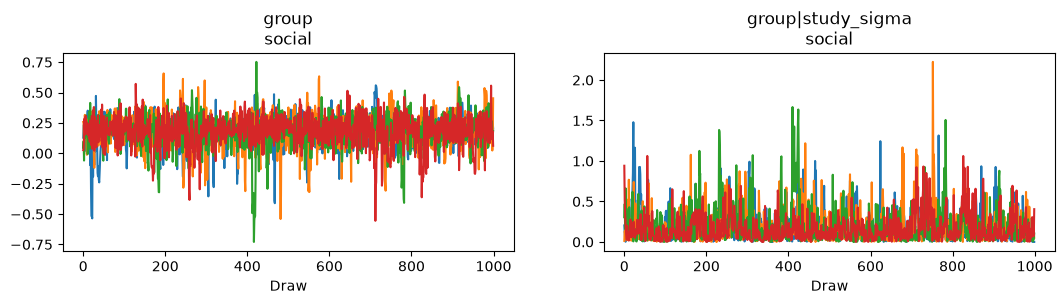

In [17]:
Regression_data = model_hierarchical.fit(draws = 1000, chains = 4, random_seed= 42, target_accept = 0.98)
summary_df = az.summary(Regression_data, ci_prob = 0.90)
main_var = ['Intercept',
            'group[social]',
            '1|study_sigma',
            'group|study_sigma[social]']
main_summary = summary_df.loc[main_var]
print(main_summary)
az.plot_trace(Regression_data,var_names = ["group", "group|study_sigma"])

H0: The descriptive social norm intervention has no effect or a negative effect on the log-odds of towel reuse.
H1: The descriptive social norm intervention positively increases the log-odds of towel reuse.

Additionally, to test for variations in efficacy across different experimental settings, we evaluate the heterogeneity hypothesis: H0: τ = 0 vs. H1: τ > 0

The hypothesis are evaluated though the 90% probability interval and posterior probability metric: The posterior distribution for the overall treatment effect μ(group[social])the mean value is 0.177, corresponding with a 90% ETI of [-0.046, 0.370]. Because this 90% interval includes zero, we cannot strictly reject the null hypothesis H0.

The posterior probability that the intervention has a positive effect is calculated as: P (μ>0|data) P(μ 
β ≈ Φ(0.177/0.130) ≈ 91.3%. This means a 91.3% posterior probability that the descriptive social norm intervention increases towel reuse. It falls slightly below the standard 95% threshold for decisive evidence.
